# Notebook 04 — Hypergraph Neural Networks pentru proteine

Ai parcurs Julia (nb 01), hypergraphurile cu simulare ODE (nb 02) și fundamentele machine learning + Flux.jl (nb 03). Acum **punem totul împreună**: deep learning aplicat pe structuri hypergraf — *Hypergraph Neural Networks* (HGNN). Asta e punte spre tema reală a stagiului tău.

**Parcurs:**
1. **De ce neural networks pe hypergraphuri?** Limitele Graph Neural Networks (GNN) pe proteine.
2. **HGNN — Hypergraph Neural Networks** [Feng et al., 2019]: matematică + implementare manuală (cu `LinearAlgebra`).
3. **Alte arhitecturi** — HyperGCN, AllSet, MPNN — și unde le găsești implementate.
4. **Aplicații în proteomică** — AlphaFold context, predicție PPI, design *de novo*, predicție de funcție.
5. **Resurse** — cărți, cursuri, comunități.

**Notă:** acest notebook are **mai mult conținut conceptual** decât 01–03 — ești la nivelul de a citi/critici paper-uri, nu doar de a executa cod. Codul existent e ilustrativ (un singur layer HGNN computat manual), nu un sistem de training complet. Pentru context ML, vezi notebook 03.

> 💡 Toate paper-urile citate au link arXiv/DOI în secțiunea **Referințe**.

## Cap. 6 — Hypergraph Neural Networks

### 6.1 De ce graphurile binare nu sunt suficiente pentru proteine

**Graph Neural Networks (GNN)** [Gilmer et al., 2017] sunt motorul deep learning pe structuri moleculare:
- noduri = atomi (sau reziduuri);
- muchii = legături chimice (sau contacte spațiale);
- message passing: fiecare nod își *agregază* informația de la vecini.

**Pentru proteine însă**, multe interacțiuni biologic-relevante NU sunt binare:

| Tip de interacțiune | Ordine | Exemplu |
|---|---|---|
| Sit catalitic | 3–7 reziduuri | tetradă His-Asp-Ser-Lys din serin-proteaze |
| Complex multi-subunitate | 2–20+ subunități | ribozomul, ATP-sintaza |
| Motiv structural | 4–10 reziduuri | β-turn, zinc finger |
| Diedru de torsiune | exact 4 atomi | unghiurile φ, ψ, χ din backbone |
| Interface PPI | 10–50 reziduuri | interfața antigen-anticorp |

Toate astea cer **relații de ordin înalt** — hypergraphuri. De aici motivația pentru *Hypergraph Neural Networks*.

### 6.2 HGNN — formula convoluției pe hypergraph

**Hypergraph Neural Networks** [Feng et al., 2019] generalizează formula convoluției pe graf [Kipf & Welling, 2017] la hypergraphuri. O **convoluție hypergraph** are forma:

$$X^{(l+1)} = \sigma\!\left( D_v^{-1/2} H W D_e^{-1} H^\top D_v^{-1/2} X^{(l)} \Theta^{(l)} \right)$$

Unde:

| Simbol | Dimensiune | Înțeles |
|---|---|---|
| $X^{(l)}$ | $n \times d_l$ | features pe noduri la layer-ul $l$ ($n$ noduri, $d_l$ trăsături) |
| $H$ | $n \times m$ | matricea de incidență (din notebook 02!) |
| $W$ | $m \times m$ diagonal | ponderi pe hyperedges (de regulă identitate) |
| $D_v$ | $n \times n$ diagonal | grad nod: $D_v[i,i] = \sum_e H_{ie} W_{ee}$ |
| $D_e$ | $m \times m$ diagonal | grad hyperedge: $D_e[e,e] = \sum_v H_{ve}$ (mărimea hyperedge-ului) |
| $\Theta^{(l)}$ | $d_l \times d_{l+1}$ | parametri **învățabili** ai layer-ului |
| $\sigma$ | element-wise | activare neliniară (de regulă ReLU sau tanh) |

**Intuiție.** Citește formula de la dreapta la stânga:
1. $X^{(l)} \Theta^{(l)}$ — proiectează features-urile fiecărui nod într-un spațiu nou (transformare liniară învățabilă).
2. $H^\top D_v^{-1/2} (\ldots)$ — agregă features-urile nodurilor în fiecare hyperedge (suma normalizată).
3. $D_e^{-1} (\ldots)$ — normalizează cu mărimea hyperedge-ului (medie, nu sumă).
4. $H W (\ldots)$ — distribuie înapoi features-urile hyperedge-urilor la nodurile incidente.
5. $D_v^{-1/2} (\ldots)$ — normalizează încă o dată cu gradul nodului.
6. $\sigma(\ldots)$ — activare neliniară.

**Comparație cu GCN:** dacă în loc de $H$ pui matricea de adiacență $A$ (cu $D = D_v = D_e$), recuperezi convoluția clasică [Kipf & Welling, 2017] $X' = \sigma(D^{-1/2} A D^{-1/2} X \Theta)$. HGNN e exact extensia la $|e| > 2$.

### 6.3 Implementare manuală — un layer HGNN pe un mini-complex proteic

Pentru a face matematica concretă, implementăm **un singur layer** HGNN pe o rețea sintetică de **complexe proteice**:
- 6 proteine ($A, B, C, D, E, F$);
- 4 complexe (fiecare un set de 3 proteine);

Toate operațiile sunt înmulțiri de matrici — folosim doar `LinearAlgebra` (stdlib Julia). Fără Flux, fără PyTorch.

In [18]:
using HyperGraphs, LinearAlgebra, Random
Random.seed!(42)   # reproducibilitate

TaskLocalRNG()

In [19]:
# 4 complexe proteice (fiecare un set de 3 proteine)
complexe = [
    HyperEdge([:A, :B, :C]),   # complex 1
    HyperEdge([:C, :D, :E]),   # complex 2
    HyperEdge([:A, :E, :F]),   # complex 3
    HyperEdge([:B, :D, :F]),   # complex 4
]
G = HyperGraph(complexe)
println("Proteine (nv = $(nv(G))): ", vertices(G))
println("Complexe (nhe = $(nhe(G))): ", nhe(G))

Proteine (nv = 6): [:A, :B, :C, :D, :E, :F]
Complexe (nhe = 4): 4


**🎨 Vizualizare** — hai să vedem hypergraph-ul de complexe pe care îl vom procesa cu HGNN:

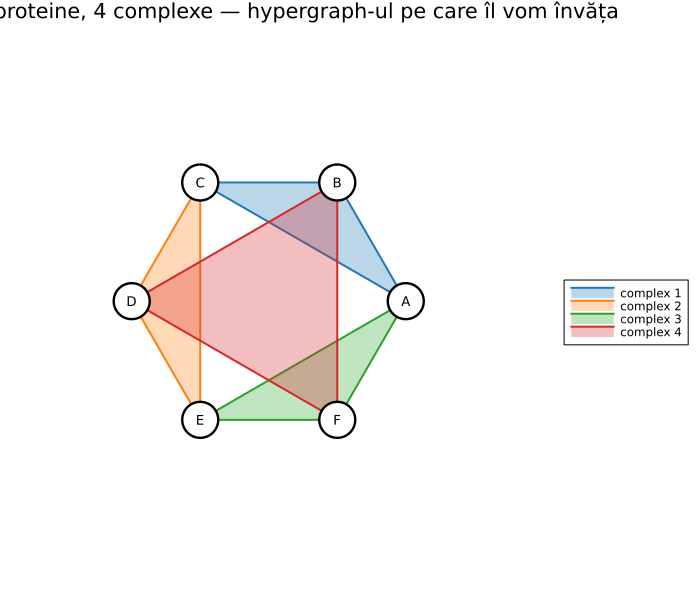

In [20]:
using Plots
using Statistics: mean

function plot_hypergraph(G; edge_alpha=0.3, size=(700, 600), title="Hypergraph")
    verts = vertices(G)
    n = length(verts)
    edges = hyperedges(G)

    angles = range(0, 2π; length=n+1)[1:n]
    pos = Dict(verts[i] => (cos(angles[i]), sin(angles[i])) for i in 1:n)

    plt = plot(aspect_ratio=:equal, legend=:outerright, grid=false,
               framestyle=:none, size=size, title=title,
               xlims=(-1.6, 2.0), ylims=(-1.5, 1.5))

    edge_vset(e) = e isa ChemicalHyperEdge ? unique(vcat(src(e), tgt(e))) : vertices(e)

    cs = palette(:tab10)
    for (j, e) in enumerate(edges)
        pts = [pos[v] for v in edge_vset(e)]
        c = cs[mod1(j, length(cs))]
        lbl = e isa ChemicalHyperEdge ? "r$j" : "complex $j"

        if length(pts) == 1
            scatter!(plt, [pts[1][1]], [pts[1][2]], ms=40, color=c,
                     alpha=edge_alpha, markerstrokewidth=0, label=lbl)
        elseif length(pts) == 2
            plot!(plt, [pts[1][1], pts[2][1]], [pts[1][2], pts[2][2]],
                  color=c, lw=20, alpha=edge_alpha, label=lbl)
        else
            xs = [p[1] for p in pts]; ys = [p[2] for p in pts]
            cx, cy = mean(xs), mean(ys)
            order = sortperm([atan(y-cy, x-cx) for (x, y) in zip(xs, ys)])
            xs_s = vcat(xs[order], xs[order[1]])
            ys_s = vcat(ys[order], ys[order[1]])
            plot!(plt, xs_s, ys_s, fill=(0, edge_alpha, c), color=c, lw=2, label=lbl)
        end
    end

    for v in verts
        scatter!(plt, [pos[v][1]], [pos[v][2]], color=:white, ms=20,
                 markerstrokewidth=2, markerstrokecolor=:black, label=false)
        annotate!(plt, pos[v][1], pos[v][2], text(string(v), 9, :center))
    end
    return plt
end

plot_hypergraph(G; title="6 proteine, 4 complexe — hypergraph-ul pe care îl vom învăța")

In [21]:
# Matricea de incidenta — 0/1, n x m
H = float.(incidence_matrix(G))

6×4 Matrix{Float64}:
 1.0  0.0  1.0  0.0
 1.0  0.0  0.0  1.0
 1.0  1.0  0.0  0.0
 0.0  1.0  0.0  1.0
 0.0  1.0  1.0  0.0
 0.0  0.0  1.0  1.0

**Matricele de grade.** $D_v$ (grad nod) și $D_e$ (grad hyperedge):

In [22]:
n, m = size(H)
D_v = Diagonal(vec(sum(H; dims=2)))   # cite complexe contine fiecare proteina
D_e = Diagonal(vec(sum(H; dims=1)))   # cite proteine are fiecare complex
W = Diagonal(ones(m))                  # ponderi uniforme pe complexe

println("D_v (grade noduri): ", diag(D_v))
println("D_e (mărimi hyperedges): ", diag(D_e))

D_v (grade noduri): [2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
D_e (mărimi hyperedges): [3.0, 3.0, 3.0, 3.0]


**Features pe noduri.** Inițializăm fiecare proteină cu un vector aleator de $d_{in}=4$ dimensiuni (ar putea reprezenta, în practică: lungime, hidrofobicitate, pI, GO-term embedding etc.).

In [23]:
d_in = 4    # număr trăsături per nod la input
d_out = 2   # număr trăsături după layer

X = randn(n, d_in)    # features inițiale
Θ = randn(d_in, d_out)  # parametri învățabili ai layer-ului

println("X (features input): $(size(X))")
println("Θ (parametri): $(size(Θ))")

X (features input): (6, 4)
Θ (parametri): (4, 2)


**Forward pass** — formula HGNN, descompusă pas cu pas:

In [24]:
# Normalizarile
D_v_inv_half = Diagonal(1 ./ sqrt.(diag(D_v)))
D_e_inv = inv(D_e)

# Pas 1: transformare liniara invatabila
step1 = X * Θ                              # n × d_out

# Pas 2: normalizare cu gradul nodului
step2 = D_v_inv_half * step1               # n × d_out

# Pas 3: agregare in hyperedges (suma)
step3 = H' * step2                          # m × d_out

# Pas 4: medie peste nodurile din fiecare hyperedge
step4 = D_e_inv * step3                     # m × d_out

# Pas 5: distribuire inapoi pe noduri
step5 = H * W * step4                       # n × d_out

# Pas 6: normalizare finala
step6 = D_v_inv_half * step5                # n × d_out

# Pas 7: activare neliniara
X_new = tanh.(step6)

println("Features noi după 1 layer HGNN (shape $(size(X_new))):")
display(X_new)

Features noi după 1 layer HGNN (shape (6, 2)):


6×2 Matrix{Float64}:
  0.377423  -0.536592
  0.48884   -0.416099
  0.83331   -0.648704
  0.577889  -0.484691
  0.479091  -0.595077
 -0.141576  -0.341153

**🎨 Vizualizare features înainte vs. după layer-ul HGNN**

Heatmap-uri side-by-side ale lui $X$ și $X_{\text{new}}$. Observă cum features-urile fiecărei proteine s-au **schimbat** după ce au "trecut prin" hypergraph (amestec cu partenerii din complexe):

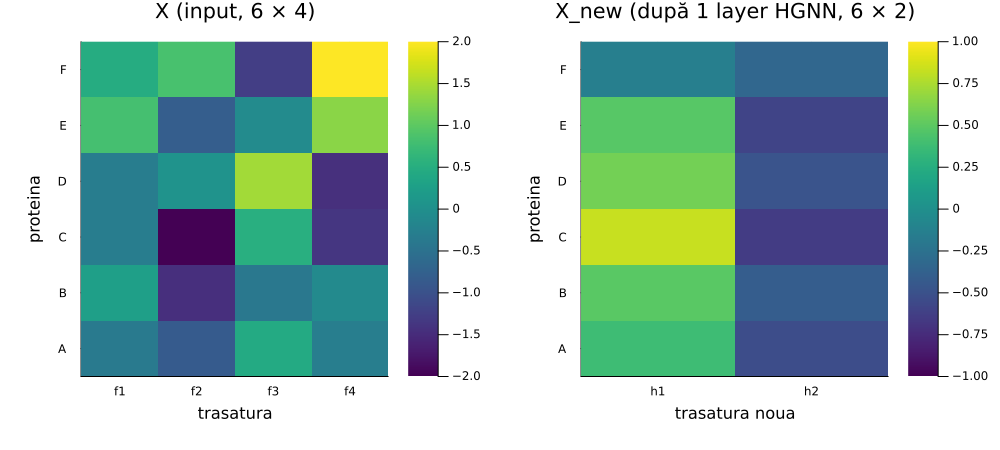

In [25]:
vlabels = string.(vertices(G))

p_X = heatmap(X, c=:viridis,
              xlabel="trasatura", ylabel="proteina",
              xticks=(1:d_in, ["f$i" for i in 1:d_in]),
              yticks=(1:nv(G), vlabels),
              title="X (input, $(nv(G)) × $d_in)",
              clim=(-2, 2))

p_Xnew = heatmap(X_new, c=:viridis,
                 xlabel="trasatura noua", ylabel="proteina",
                 xticks=(1:d_out, ["h$i" for i in 1:d_out]),
                 yticks=(1:nv(G), vlabels),
                 title="X_new (după 1 layer HGNN, $(nv(G)) × $d_out)",
                 clim=(-1, 1))

plot(p_X, p_Xnew, layout=(1, 2), size=(1000, 450),
     left_margin=10Plots.mm, bottom_margin=10Plots.mm, top_margin=5Plots.mm)

**Citirea rezultatului.** Fiecare rând e o proteină, fiecare coloană e o trăsătură nouă. Diferența de la `X` la `X_new`: features-urile fiecărei proteine **au fost amestecate cu features-urile partenerilor săi din complexe**, prin matricea de incidență.

**Asta e "message passing"** la nivel de hypergraph: nu trec mesaje doar între perechi de noduri (ca în GNN), ci între *toate nodurile dintr-o hyperedge simultan*.

În practica de training:
- $\Theta^{(l)}$ ar fi învățat prin **backpropagation** pe o sarcină supervizată (ex: clasificarea funcțională a proteinei, predicție PPI, etc.);
- am compune **mai multe layere** ($L = 2$–$8$ tipic) pentru a propaga informația prin rețea;
- am folosi un framework de deep learning (PyTorch + PyG/DGL în Python, sau Flux + GraphNeuralNetworks.jl în Julia).

### 🎬 Animație — message passing vizual pe hypergraph

Hai să **vedem** cum funcționează message passing. Vom anima procesul în 4 faze:

1. **Input X** — features inițiale per nod (color-coded: albastru = pozitiv, roșu = negativ);
2. **Agregare** — fiecare hyperedge "colectează" features de la nodurile incidente (highlight secvențial);
3. **Actualizare** — nodurile primesc înapoi features agregate, culori tranzitionează spre `X_new`;
4. **X_new** — features finale după 1 layer HGNN.

Folosim prima coloană (`X[:,1] → X_new[:,1]`) pentru color-coding.

*Notă tehnică:* ar fi fost ideal cu [Javis.jl](https://juliaanimators.github.io/Javis.jl/) (stil 3Blue1Brown), dar versiunea compatibilă cu Julia 1.12 (v0.1.5) are un API vechi limitat; obținem same insight cu `@animate` din Plots.jl.

[ Info: Saved animation to C:\Users\danmu\Documents\anastasia\notebooks\tmp.gif


Plots.AnimatedGif("C:\\Users\\danmu\\Documents\\anastasia\\notebooks\\tmp.gif")
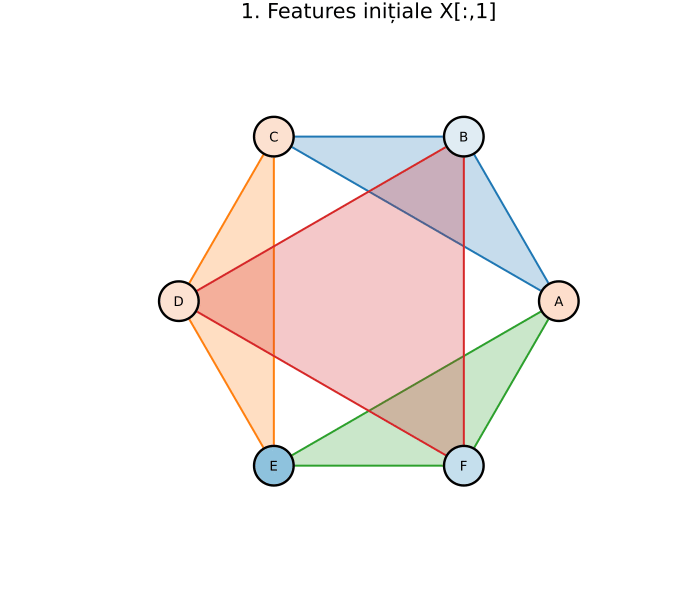

In [26]:
# Variantă a lui plot_hypergraph cu noduri color-coded după o valoare numerică,
# plus posibilitatea de a evidenția (focus) un hyperedge specific.
function plot_hg_step(G, node_vals; edge_focus=0, edge_alpha=0.25,
                      title="", clim=(-2, 2), size=(700, 600))
    verts = vertices(G)
    n_v = length(verts)
    edges = hyperedges(G)

    angles = range(0, 2π; length=n_v+1)[1:n_v]
    pos = Dict(verts[i] => (cos(angles[i]), sin(angles[i])) for i in 1:n_v)

    plt = plot(aspect_ratio=:equal, legend=false, grid=false,
               framestyle=:none, size=size, title=title,
               xlims=(-1.6, 1.6), ylims=(-1.4, 1.4))

    cs = palette(:tab10)
    edge_vset(e) = e isa ChemicalHyperEdge ? unique(vcat(src(e), tgt(e))) : vertices(e)

    for (j, e) in enumerate(edges)
        pts = [pos[v] for v in edge_vset(e)]
        c = cs[mod1(j, length(cs))]
        alpha = (edge_focus == j) ? 0.7 : edge_alpha
        xs = [p[1] for p in pts]; ys = [p[2] for p in pts]
        cx, cy = mean(xs), mean(ys)
        order = sortperm([atan(y-cy, x-cx) for (x, y) in zip(xs, ys)])
        xs_s = vcat(xs[order], xs[order[1]])
        ys_s = vcat(ys[order], ys[order[1]])
        plot!(plt, xs_s, ys_s, fill=(0, alpha, c), color=c, lw=2)
    end

    for (i, v) in enumerate(verts)
        val = node_vals[i]
        clamped = clamp((val - clim[1]) / (clim[2] - clim[1]), 0, 1)
        nodecolor = cgrad(:RdBu)[clamped]
        scatter!(plt, [pos[v][1]], [pos[v][2]], color=nodecolor, ms=22,
                 markerstrokewidth=2, markerstrokecolor=:black)
        annotate!(plt, pos[v][1], pos[v][2], text(string(v), 9, :black))
    end

    return plt
end

# Folosim prima coloana de features pentru color-coding
vals_in_anim = vec(X[:, 1])
vals_out_anim = vec(X_new[:, 1])

# Construim secventa de frame-uri
frames = []
for f in 1:8;  push!(frames, (vals_in_anim, 0, "1. Features inițiale X[:,1]")); end
for j in 1:nhe(G), f in 1:5
    push!(frames, (vals_in_anim, j, "2. Hyperedge $j agregă features"))
end
for f in 1:18
    t = f / 18
    push!(frames, ((1-t).*vals_in_anim .+ t.*vals_out_anim, 0,
                   "3. Features se actualizează"))
end
for f in 1:10; push!(frames, (vals_out_anim, 0, "4. X_new[:,1] după 1 layer HGNN")); end

anim = @animate for (vals, focus, ttl) in frames
    plot_hg_step(G, vals; edge_focus=focus, title=ttl)
end

gif(anim, fps=10)

### 6.4 Alte arhitecturi de Hypergraph Neural Networks

HGNN [Feng et al., 2019] e *baseline-ul*. De atunci s-au dezvoltat variante mai sofisticate:

| Arhitectură | Idee centrală | Citație |
|---|---|---|
| **HGNN** | Convoluție spectrală via matrice de incidență (cea de mai sus) | [Feng et al., 2019] |
| **HyperGCN** | Reduce hypergraph la graf clasic via *mediating vertices* | [Yadati et al., 2019] |
| **HGAT** | Adaugă mecanism de **atenție** pe hyperedges | [Bai et al., 2021] |
| **AllSet / AllSetTransformer** | Cadru unificator — orice funcție pe multiseturi e validă | [Chien et al., 2022] |
| **EDGNN** | Edge-aware: tratează heterogenitatea hyperedge-urilor | [Wang et al., 2023] |
| **UniGNN** | Unifică HGNN cu GCN/GAT/GIN | [Huang & Yang, 2021] |

**AllSetTransformer** [Chien et al., 2022] e considerat *state-of-the-art* la ora actuală pe benchmark-urile standard de hypergraph learning. Folosește un mecanism transformer pentru agregarea features-urilor în hyperedges.

### 6.5 Unde se antrenează — frameworks

**Python (dominant pentru ML pe grafuri):**
- [**PyTorch Geometric (PyG)**](https://pytorch-geometric.readthedocs.io/) — include `HypergraphConv` și alte layere de hypergraph.
- [**DGL**](https://www.dgl.ai/) — Deep Graph Library, suport pentru hypergraphuri în `dgl.DGLHyperGraph`.
- [**TorchHG**](https://github.com/iMoonLab/TorchHypergraph) — bibliotecă dedicată de la autorii HGNN.

**Julia (mai puțin matur, dar în creștere):**
- [**GraphNeuralNetworks.jl**](https://github.com/CarloLucibello/GraphNeuralNetworks.jl) — partea GNN clasică; suport pentru hypergraphuri e limitat la momentul redactării.
- [**Flux.jl**](https://fluxml.ai/Flux.jl/) — framework general de ML; poți construi un HGNN manual pe baza formulei de mai sus.
- Combinația **`HyperGraphs.jl` (structură) + `Flux.jl` (învățare)** e fezabilă, dar va trebui să implementezi layer-ele singură.

Recomandare practică: **dacă tema stagiului implică ML pe hypergraphuri, întrebă coordonatorul** dacă preferă Python (PyG) sau Julia (Flux + HyperGraphs.jl). Acesta e tipul de detaliu pe care îl decide grupul de cercetare.

## 🧬 De la proteine abstracte la proteine reale — vizualizare 3D

Până acum, am tratat proteinele ca **simboluri abstracte** (`:A`, `:B`, …). În realitate, fiecare proteină are o **structură 3D complexă** determinată de secvența ei. Pentru proiectul tău vei lucra probabil cu structuri reale din [Protein Data Bank (PDB)](https://www.rcsb.org/) sau predicții AlphaFold.

**Bio3DView.jl** [Greener, 2018] e un pachet Julia care wrap-uiește [3Dmol.js](https://3dmol.csb.pitt.edu/) — un viewer interactiv browser-based pentru molecule. Funcționează nativ în Jupyter.

Ca să facem legătura cu nb 02 (rețeaua de fosforilare), vom vizualiza **CDK2** — *cyclin-dependent kinase 2* — o kinază reală care fosforilează substrate în reglarea ciclului celular. PDB ID: **1HCK**.

In [27]:
using Pkg
Pkg.add("Bio3DView")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\danmu\.julia\environments\v1.12\Manifest.toml`


In [28]:
using Bio3DView

# CDK2 — Cyclin-dependent kinase 2 (PDB ID: 1HCK)
# Folosim html=true + HTML() pentru rendering garantat in Jupyter
HTML(viewpdb("1HCK"; html=true))

HTML{String}("<html>\n<meta charset=\"UTF-8\">\n<head></head>\n<body><script type='text/javascript'>/*! jQuery v3.3.1 | (c) JS Foundation and other contributors | jquery.org/license */\n!function(e,t){\"use strict\";\"object\"==typeof module&&\"object\"==typeof module.exports?module.exports=e.document?t(e,!0):function(e){if(!e.document)throw new Error(\"jQuery requires a window with a document\");return t(e)}:t(e)}(\"undefined\"!=typeof window?window:this,function(e,t){\"use strict\";var n=[],r=e.document,i=Object.getPrototypeOf,o=n.slice,a=n.concat,s=n.push,u=n.indexOf,l={},c=l.toString,f=l.hasOwnProperty,p=f.toString,d=p.call(Object),h={},g=function e(t){return\"function\"==typeof t&&\"number\"!=typeof t.nodeType},y=function e(t){return null!=t&&t===t.window},v={type:!0,src:!0,noModule:!0};function m(e,t,n){var i,o=(t=t||r).createElement(\"script\");if(o.text=e,n)for(i in v)n[i]&&(o[i]=n[i]);t.head.appendChild(o).parentNode.removeChild(o)}function x(e){return null==e?e+\"\":\"object\"==typeof e||\"function\"==typeof e?l[c.call(e)]||\"object\":typeof e}var b=\"3.3.1\",w=function(e,t){return new w.fn.init(e,t)},T=/^[\\s\\uFEFF\\xA0]+|[\\s\\uFEFF\\xA0]+\$/g;w.fn=w.prototype={jquery:\"3.3.1\",constructor:w,length:0,toArray:function(){return o.call(this)},get:function(e){return null==e?o.call(this):e<0?this[e+this.length]:this[e]},pushStack:function(e){var t=w.merge(this.constructor(),e);return t.prevObject=this,t},each:function(e){return w.each(this,e)},map:function(e){return this.pushStack(w.map(this,function(t,n){return e.call(t,n,t)}))},slice:function(){return this.pushStack(o.apply(this,arguments))},first:function(){return this.eq(0)},last:function(){return this.eq(-1)},eq:function(e){var t=this.length,n=+e+(e<0?t:0);return this.pushStack(n>=0&&n<t?[this[n]]:[])},end:function(){return this.prevObject||this.constructor()},push:s,sort:n.sort,splice:n.splice},w.extend=w.fn.extend=function(){var e,t,n,r,i,o,a=arguments[0]||{},s=1,u=arguments.length,l=!1;for(\"boolean\"==typeof a&&(l=a,a=arguments[s]||{},s++),\"object\"==typeof a||g(a)||(a={}),s===u&&(a=this,s--);s<u;s++)if(null!=(e=arguments[s]))for(t in e)n=a[t],a!==(r=e[t])&&(l&&r&&(w.isPlainObject(r)||(i=Array.isArray(r)))?(i?(i=!1,o=n&&Array.isArray(n)?n:[]):o=n&&w.isPlainObject(n)?n:{},a[t]=w.extend(l,o,r)):void 0!==r&&(a[t]=r));return a},w.extend({expando:\"jQuery\"+(\"3.3.1\"+Math.random()).replace(/\\D/g,\"\"),isReady:!0,error:function(e){throw new Error(e)},noop:function(){},isPlainObject:function(e){var t,n;return!(!e||\"[object Object]\"!==c.call(e))&&(!(t=i(e))||\"function\"==typeof(n=f.call(t,\"constructor\")&&t.constructor)&&p.call(n)===d)},isEmptyObject:function(e){var t;for(t in e)return!1;return!0},globalEval:function(e){m(e)},each:function(e,t){var n,r=0;if(C(e)){for(n=e.length;r<n;r++)if(!1===t.call(e[r],r,e[r]))break}else for(r in e)if(!1===t.call(e[r],r,e[r]))break;return e},trim:function(e){return null==e?\"\":(e+\"\").replace(T,\"\")},makeArray:function(e,t){var n=t||[];return null!=e&&(C(Object(e))?w.merge(n,\"string\"==typeof e?[e]:e):s.call(n,e)),n},inArray:function(e,t,n){return null==t?-1:u.call(t,e,n)},merge:function(e,t){for(var n=+t.length,r=0,i=e.length;r<n;r++)e[i++]=t[r];return e.length=i,e},grep:function(e,t,n){for(var r,i=[],o=0,a=e.length,s=!n;o<a;o++)(r=!t(e[o],o))!==s&&i.push(e[o]);return i},map:function(e,t,n){var r,i,o=0,s=[];if(C(e))for(r=e.length;o<r;o++)null!=(i=t(e[o],o,n))&&s.push(i);else for(o in e)null!=(i=t(e[o],o,n))&&s.push(i);return a.apply([],s)},guid:1,support:h}),\"function\"==typeof Symbol&&(w.fn[Symbol.iterator]=n[Symbol.iterator]),w.each(\"Boolean Number String Function Array Date RegExp Object Error Symbol\".split(\" \"),function(e,t){l[\"[object \"+t+\"]\"]=t.toLowerCase()});function C(e){var t=!!e&&\"length\"in e&&e.length,n=x(e);return!g(e)&&!y(e)&&(\"array\"===n||0===t||\"number\"==typeof t&&t>0&&t-1 in e)}var E=function(e){var t,n,r,i,o,a,s,u,l,c,f,p,d,h,g,y,v,m,x,b=\"sizzle\"+1*new Date,w=e.document,T=0,C=0,E=ae(),

Vizualizarea de mai sus e **interactivă**: în Jupyter live poți să o rotești cu mouse-ul, să faci zoom, să schimbi stilul. Default-ul folosește reprezentarea *cartoon* — fiecare elicozioală e o spirală, fiecare foaie β o săgeată plată.

**Stiluri custom** — putem alege reprezentări diferite. *Cartoon colorat spectral* (rainbow N-terminal → C-terminal) ne arată direcția polipeptidului:

In [29]:
HTML(viewpdb("1HCK";
             style=Style("cartoon", Dict("colorscheme" => "spectrum")),
             html=true))

HTML{String}("<html>\n<meta charset=\"UTF-8\">\n<head></head>\n<body><script type='text/javascript'>/*! jQuery v3.3.1 | (c) JS Foundation and other contributors | jquery.org/license */\n!function(e,t){\"use strict\";\"object\"==typeof module&&\"object\"==typeof module.exports?module.exports=e.document?t(e,!0):function(e){if(!e.document)throw new Error(\"jQuery requires a window with a document\");return t(e)}:t(e)}(\"undefined\"!=typeof window?window:this,function(e,t){\"use strict\";var n=[],r=e.document,i=Object.getPrototypeOf,o=n.slice,a=n.concat,s=n.push,u=n.indexOf,l={},c=l.toString,f=l.hasOwnProperty,p=f.toString,d=p.call(Object),h={},g=function e(t){return\"function\"==typeof t&&\"number\"!=typeof t.nodeType},y=function e(t){return null!=t&&t===t.window},v={type:!0,src:!0,noModule:!0};function m(e,t,n){var i,o=(t=t||r).createElement(\"script\");if(o.text=e,n)for(i in v)n[i]&&(o[i]=n[i]);t.head.appendChild(o).parentNode.removeChild(o)}function x(e){return null==e?e+\"\":\"object\"==typeof e||\"function\"==typeof e?l[c.call(e)]||\"object\":typeof e}var b=\"3.3.1\",w=function(e,t){return new w.fn.init(e,t)},T=/^[\\s\\uFEFF\\xA0]+|[\\s\\uFEFF\\xA0]+\$/g;w.fn=w.prototype={jquery:\"3.3.1\",constructor:w,length:0,toArray:function(){return o.call(this)},get:function(e){return null==e?o.call(this):e<0?this[e+this.length]:this[e]},pushStack:function(e){var t=w.merge(this.constructor(),e);return t.prevObject=this,t},each:function(e){return w.each(this,e)},map:function(e){return this.pushStack(w.map(this,function(t,n){return e.call(t,n,t)}))},slice:function(){return this.pushStack(o.apply(this,arguments))},first:function(){return this.eq(0)},last:function(){return this.eq(-1)},eq:function(e){var t=this.length,n=+e+(e<0?t:0);return this.pushStack(n>=0&&n<t?[this[n]]:[])},end:function(){return this.prevObject||this.constructor()},push:s,sort:n.sort,splice:n.splice},w.extend=w.fn.extend=function(){var e,t,n,r,i,o,a=arguments[0]||{},s=1,u=arguments.length,l=!1;for(\"boolean\"==typeof a&&(l=a,a=arguments[s]||{},s++),\"object\"==typeof a||g(a)||(a={}),s===u&&(a=this,s--);s<u;s++)if(null!=(e=arguments[s]))for(t in e)n=a[t],a!==(r=e[t])&&(l&&r&&(w.isPlainObject(r)||(i=Array.isArray(r)))?(i?(i=!1,o=n&&Array.isArray(n)?n:[]):o=n&&w.isPlainObject(n)?n:{},a[t]=w.extend(l,o,r)):void 0!==r&&(a[t]=r));return a},w.extend({expando:\"jQuery\"+(\"3.3.1\"+Math.random()).replace(/\\D/g,\"\"),isReady:!0,error:function(e){throw new Error(e)},noop:function(){},isPlainObject:function(e){var t,n;return!(!e||\"[object Object]\"!==c.call(e))&&(!(t=i(e))||\"function\"==typeof(n=f.call(t,\"constructor\")&&t.constructor)&&p.call(n)===d)},isEmptyObject:function(e){var t;for(t in e)return!1;return!0},globalEval:function(e){m(e)},each:function(e,t){var n,r=0;if(C(e)){for(n=e.length;r<n;r++)if(!1===t.call(e[r],r,e[r]))break}else for(r in e)if(!1===t.call(e[r],r,e[r]))break;return e},trim:function(e){return null==e?\"\":(e+\"\").replace(T,\"\")},makeArray:function(e,t){var n=t||[];return null!=e&&(C(Object(e))?w.merge(n,\"string\"==typeof e?[e]:e):s.call(n,e)),n},inArray:function(e,t,n){return null==t?-1:u.call(t,e,n)},merge:function(e,t){for(var n=+t.length,r=0,i=e.length;r<n;r++)e[i++]=t[r];return e.length=i,e},grep:function(e,t,n){for(var r,i=[],o=0,a=e.length,s=!n;o<a;o++)(r=!t(e[o],o))!==s&&i.push(e[o]);return i},map:function(e,t,n){var r,i,o=0,s=[];if(C(e))for(r=e.length;o<r;o++)null!=(i=t(e[o],o,n))&&s.push(i);else for(o in e)null!=(i=t(e[o],o,n))&&s.push(i);return a.apply([],s)},guid:1,support:h}),\"function\"==typeof Symbol&&(w.fn[Symbol.iterator]=n[Symbol.iterator]),w.each(\"Boolean Number String Function Array Date RegExp Object Error Symbol\".split(\" \"),function(e,t){l[\"[object \"+t+\"]\"]=t.toLowerCase()});function C(e){var t=!!e&&\"length\"in e&&e.length,n=x(e);return!g(e)&&!y(e)&&(\"array\"===n||0===t||\"number\"==typeof t&&t>0&&t-1 in e)}var E=function(e){var t,n,r,i,o,a,s,u,l,c,f,p,d,h,g,y,v,m,x,b=\"sizzle\"+1*new Date,w=e.document,T=0,C=0,E=ae(),

**Legătura cu nb 02:** CDK2 e exact tipul de proteină care apare în rețeaua de fosforilare modelată acolo (`E` din `E + M → E_M → pE + M`). Aici vezi geometria 3D reală a unei astfel de kinaze.

**Pentru aplicații cu hypergraph-uri pe proteine**, vizualizarea 3D este esențială pentru:
- a defini ce înseamnă "reziduuri vecine" (contact spațial < 8 Å);
- a identifica situri active și buzunare de legare;
- a debug-a vizual rețelele extrase din structuri.

**Pachete Julia complementare:**
- [`BioStructures.jl`](https://github.com/BioJulia/BioStructures.jl) — citire/manipulare PDB programatică (extragere atoms, lanțuri, distanțe, contacte).
- [`MolecularGraph.jl`](https://github.com/mojaie/MolecularGraph.jl) — grafuri moleculare din SMILES.
- [`Chemfiles.jl`](https://github.com/chemfiles/Chemfiles.jl) — I/O pentru ~80 formate moleculare.

## Cap. 7 — Aplicații în proteomică

### 7.1 Contextul mare: AlphaFold și modelele de limbaj pentru proteine

Înainte de hypergraph-uri, contextul ML pentru proteine în 2024+ se rezumă la două revoluții:

1. **AlphaFold 2** [Jumper et al., 2021] — predicție de structură 3D din secvență cu precizie aproape experimentală. Folosește attention pe coloane MSA + perechi reziduu-reziduu. NU e hypergraph, dar a redefinit câmpul.
2. **ESM-2 / ESMFold** [Lin et al., 2023] — modele de limbaj evolutiv (transformer) pe secvențe de proteine. Generează embeddings utile downstream.

Aceste modele rezolvă problema *single-protein structure prediction*. **Hypergraph-urile aduc valoare** pe sarcini de ordin înalt — **interacțiuni, complexe, funcții emergente**.

### 7.2 Hypergraph-uri pentru proteine — direcții active de cercetare

*Notă: lista e descriptivă, nu prescriptivă. Direcția exactă a stagiului tău o vei afla de la coordonator.*

#### A. Predicție de interacțiuni proteină-proteină (PPI)
- Hypergraph: noduri = proteine, hyperedges = complexe sau căi de semnalizare.
- Task: prezicere de noi interacțiuni (legături lipsă în rețea).
- Referințe: [Liu et al., 2022], [Hwang et al., 2022].

#### B. Predicție de funcție (Gene Ontology, EC numbers)
- Hypergraph: noduri = proteine, hyperedges = clasificări funcționale comune.
- Task: dată o proteină nouă, prezicere termenii GO sau funcția enzimatică.
- Referințe: [Kulmanov & Hoehndorf, 2020] (DeepGOPlus), extensii cu hypergraphuri [Wang et al., 2023].

#### C. Design *de novo* de proteine
- Hypergraph: noduri = reziduuri sau motive structurale, hyperedges = constrângeri structurale (situri active, simetrii).
- Task: generare de secvențe care satisfac multiple constrângeri.
- Referințe: [Watson et al., 2023] (RFdiffusion), context geometric din [Bronstein et al., 2021].

#### D. Structură de complexe multi-subunitate
- Hypergraph: subunități = noduri, interfețe multi-subunitate = hyperedges.
- Task: predicție de stoichiometrie și geometrie pentru complexe care nu se rezolvă cu AlphaFold-Multimer.
- Referințe: [Bryant et al., 2022] (AlphaFold-Multimer), extensii hypergraph în lucru.

#### E. Drug discovery
- Hypergraph: noduri = molecule + ținte, hyperedges = perechi medicament-țintă-efect.
- Task: prezicere de efecte secundare, sinergii medicamentoase.
- Referințe: [Saberi et al., 2024].

**Forward pointer:** când Anastasia află tema exactă, vom face un mini-supliment focalizat la acest notebook.

## Cap. 8 — Resurse pentru aprofundare

### Cărți (lectură serioasă)
- **Bronstein, M. M., Bruna, J., Cohen, T., & Veličković, P. (2021).** *Geometric Deep Learning*. [arXiv:2104.13478](https://arxiv.org/abs/2104.13478) — cadrul unificator pentru DL pe grafuri, manifolduri, grupuri.
- **Murphy, K. (2022).** *Probabilistic Machine Learning: An Introduction*. MIT Press. [Free online](https://probml.github.io/pml-book/).
- **Hamilton, W. L. (2020).** *Graph Representation Learning*. Morgan & Claypool. [Free online](https://www.cs.mcgill.ca/~wlh/grl_book/).

### Cursuri online (gratuite)
- **Stanford CS224W** — Machine Learning with Graphs (Leskovec). [YouTube](https://www.youtube.com/playlist?list=PLoROMvodv4rPLKxIpqhjhPgdQy7imNkDn) + [website](https://web.stanford.edu/class/cs224w/).
- **MIT 6.S898** — Deep Learning. Include track de geometric deep learning.
- **Julia Academy** — pentru aprofundare Julia. [juliaacademy.com](https://juliaacademy.com/).

### Comunități și forum-uri
- **JuliaLang Discourse** (`#help`, `#machine-learning`, `#biology`) — <https://discourse.julialang.org/>
- **Julia Slack** (canal `#biology`) — invitație via [julialang.org/community](https://julialang.org/community/).
- **BioJulia** — colecție de pachete pentru bioinformatică în Julia. [github.com/BioJulia](https://github.com/BioJulia).

### Conferințe relevante
- **NeurIPS** — workshop annual *Learning on Graphs (LoG)*.
- **ICLR**, **ICML** — track graph learning.
- **RECOMB**, **ISMB** — bioinformatică computațională.

### Paper-uri esențiale pentru a citi în primele 2 săptămâni de stagiu
1. [Feng et al., 2019] — HGNN, baseline-ul.
2. [Kipf & Welling, 2017] — GCN, fundalul.
3. [Bronstein et al., 2021] — Geometric Deep Learning, cadrul.
4. [Diaz & Stumpf, 2022] — paper-ul HyperGraphs.jl (deja parcurs în notebook 02).
5. Cel mai recent review pe topica specifică a stagiului — întreabă coordonatorul.

## Exerciții

Soluțiile sunt mai jos.

### Exercițiul 1 — Două layere HGNN

În rețelele reale, se compun mai multe layere HGNN consecutive ($L = 2$–$8$). Aplică formula de două ori, cu parametri diferiți ($\Theta^{(1)}, \Theta^{(2)}$). Iese din $d_{in}=4$ → $d_{hidden}=8$ → $d_{out}=2$.

*Hint:* extrage forward pass-ul într-o funcție `hgnn_layer(X, Θ, H, D_v, D_e, W)` și aplică-o de două ori cu Θ-uri diferite.

In [30]:
# Scrie aici solutia ta — Exercitiul 1


### Exercițiul 2 — Statistici de grade pe rețeaua de fosforilare

Rețeaua de fosforilare din notebook 02 e și ea un hypergraph (cu hyperedges = reacții). Reconstruiește-o aici și calculează:
1. **Gradul fiecărei specii** (în câte reacții participă).
2. **Mărimea fiecărei reacții** (câte specii implică, considerând reactanți + produși).
3. Care specie e cea mai "hub" (apare în cele mai multe reacții)?

*Hint:* construiește un `HyperGraph` cu `HyperEdge`-uri care grupează reactantii + produsii fiecărei reacții. Matricea de incidență e 0/1 (nu signed).

In [31]:
# Scrie aici solutia ta — Exercitiul 2


### Exercițiul 3 — Hypergraph vs graf binar

Pentru hypergraph-ul de complexe proteice ($G$ din Cap. 6.3), construiește **"graful liniei"** (line graph): două proteine sunt conectate cu o muchie clasică dacă apar împreună într-un complex.

1. Calculează **matricea de adiacență** $A$ a grafului liniei: $A_{ij} = 1$ ⇔ proteinele $i$ și $j$ apar împreună în vreun complex (și $i \neq j$).
2. Compară $A$ cu $H H^\top$. Ce relație observi?
3. Discuție: ce informație **se pierde** când reduci hypergraph-ul la graf clasic prin această "proiecție clique-expansion"?

*Hint:* matematic, $H H^\top - D_v$ are 0 pe diagonală și numărul de complexe comune între perechi pe off-diagonal. Binarizezi cu `Int.(M .> 0)`.

In [32]:
# Scrie aici solutia ta — Exercitiul 3


## Soluții

*Nu citi înainte să fi încercat singură.*

In [33]:
# Solutia 1 — Doua layere HGNN
function hgnn_layer(X, Θ, H, D_v_inv_half, D_e_inv, W)
    return tanh.(D_v_inv_half * H * W * D_e_inv * H' * D_v_inv_half * X * Θ)
end

Random.seed!(42)
Θ1 = randn(4, 8)   # 4 → 8
Θ2 = randn(8, 2)   # 8 → 2

X1 = hgnn_layer(X, Θ1, H, D_v_inv_half, D_e_inv, W)
X2 = hgnn_layer(X1, Θ2, H, D_v_inv_half, D_e_inv, W)

println("Shape după layer 1: ", size(X1))
println("Shape după layer 2: ", size(X2))
println("Features finale (2D embedding per proteină):")
display(X2)

Shape după layer 1: (6, 8)
Shape după layer 2: (6, 2)
Features finale (2D embedding per proteină):


6×2 Matrix{Float64}:
 0.656012  -0.950542
 0.580625  -0.935897
 0.49757   -0.945655
 0.328583  -0.907273
 0.433026  -0.928215
 0.523355  -0.915462

In [34]:
# Solutia 2 — Statistici de grade pe rețeaua de fosforilare

# Reconstruim rețeaua ca HyperGraph (unsigned, reactanți + produși împreună)
reactii_unsigned = [
    HyperEdge([:E, :M, :E_M]),    # r1 + r2 (binding/unbinding — același set)
    HyperEdge([:E_M, :pE, :M]),   # r3 (fosforilare #1)
    HyperEdge([:pE, :M, :pE_M]),  # r4 + r5
    HyperEdge([:pE_M, :ppE, :M]), # r6 (fosforilare #2)
]
G_ph = HyperGraph(reactii_unsigned)

H_ph = float.(incidence_matrix(G_ph))
println("Specii: ", vertices(G_ph))
println("Numar reactii (după contopirea reversibilelor): ", nhe(G_ph))

# Grade noduri
grade_specii = vec(sum(H_ph; dims=2))
println("\nGradul fiecarei specii:")
for (i, sp) in enumerate(vertices(G_ph))
    println("  $sp: $(Int(grade_specii[i]))")
end

# Mărimi hyperedges
marimi = vec(sum(H_ph; dims=1))
println("\nMărimea fiecărei reacții:")
for (i, r) in enumerate(hyperedges(G_ph))
    println("  Reacția $i ($(vertices(r))): mărime $(Int(marimi[i]))")
end

# Hub-ul
i_max = argmax(grade_specii)
println("\nSpecia hub: $(vertices(G_ph)[i_max]) cu grad $(Int(grade_specii[i_max]))")

Specii: [:E, :M, :E_M, :pE, :pE_M, :ppE]
Numar reactii (după contopirea reversibilelor): 4

Gradul fiecarei specii:
  E: 1
  M: 4
  E_M: 2
  pE: 2
  pE_M: 2
  ppE: 1

Mărimea fiecărei reacții:
  Reacția 1 ([:E, :M, :E_M]): mărime 3
  Reacția 2 ([:E_M, :pE, :M]): mărime 3
  Reacția 3 ([:pE, :M, :pE_M]): mărime 3
  Reacția 4 ([:pE_M, :ppE, :M]): mărime 3

Specia hub: M cu grad 4


In [35]:
# Solutia 3 — Hypergraph vs graf binar (clique-expansion)

# Matricea "co-apariție": M[i,j] = câte complexe contin AMÂNDOUĂ proteinele i si j
M = H * H'   # n x n
println("H * Hᵀ (co-apariție; diagonal = grad):")
display(M)

# Matricea de adiacenta a grafului liniei = M binarizat, fara diagonala
A = Int.((M - Diagonal(M)) .> 0)
println("\nMatricea de adiacență A:")
display(A)

println("\nDiscuție: H * Hᵀ păstrează **multiplicitățile** (cite complexe comune între perechi).")
println("Binarizând la A, pierdem această informație — un complex {A,B,C} produce 3 muchii (A-B, A-C, B-C), nedistinct de 3 complexe binare separate.")
println("De aceea HGNN > GCN(clique-expansion) pe sarcini sensibile la ordinea de interacțiune.")

H * Hᵀ (co-apariție; diagonal = grad):


6×6 Matrix{Float64}:
 2.0  1.0  1.0  0.0  1.0  1.0
 1.0  2.0  1.0  1.0  0.0  1.0
 1.0  1.0  2.0  1.0  1.0  0.0
 0.0  1.0  1.0  2.0  1.0  1.0
 1.0  0.0  1.0  1.0  2.0  1.0
 1.0  1.0  0.0  1.0  1.0  2.0


Matricea de adiacență A:


6×6 Matrix{Int64}:
 0  1  1  0  1  1
 1  0  1  1  0  1
 1  1  0  1  1  0
 0  1  1  0  1  1
 1  0  1  1  0  1
 1  1  0  1  1  0


Discuție: H * Hᵀ păstrează **multiplicitățile** (cite complexe comune între perechi).
Binarizând la A, pierdem această informație — un complex {A,B,C} produce 3 muchii (A-B, A-C, B-C), nedistinct de 3 complexe binare separate.
De aceea HGNN > GCN(clique-expansion) pe sarcini sensibile la ordinea de interacțiune.


## Ce ai învățat în acest notebook

- ✅ **De ce HGNN?** Multe interacțiuni biologice (situri catalitice, complexe, motive) sunt de ordin înalt — graphurile binare le sărăcesc.
- ✅ **HGNN math** — formula spectrală cu $H$, $D_v$, $D_e$, $W$, $\Theta$.
- ✅ **Implementare manuală** — un layer HGNN într-o duzină de linii de Julia + `LinearAlgebra`.
- ✅ **Compunere de layere** — același bloc aplicat secvențial, ca în orice rețea adâncă.
- ✅ **Frameworks** — PyG / DGL (Python, mature), Flux.jl + GraphNeuralNetworks.jl (Julia, în creștere).
- ✅ **Aplicații în proteomică** — survey PPI, GO, design, complexe, drug discovery.
- ✅ **Resurse** — cărți, cursuri, comunități, conferințe — tot ce e nevoie pentru continuare independentă.

## Handoff — ce să-l intrebi pe coordonator

Acum ai o bază solidă. Întrebări utile pentru prima întâlnire la UCD:
1. **Direcția exactă** — PPI, design *de novo*, predicție de funcție, complexe, drug-target?
2. **Limbaj** — continuăm în Julia (HyperGraphs.jl + Flux), sau trecem la Python (PyG/DGL)?
3. **Dataset** — există unul intern, sau folosim public (CORUM, STRING, IntAct)?
4. **Benchmark/baseline** — cu ce arhitectură comparăm? GCN? HGNN baseline? AllSet?
5. **Compute** — există acces la GPU/cluster, sau lucrăm pe laptop?

*Succes la stagiu! Și amintește-ți: hypergraphul nu e doar o structură de date — e o lentilă prin care biologia complexă devine matematică tratabilă.*

## Referințe

### Hypergraph Neural Networks
- **Feng, Y., You, H., Zhang, Z., Ji, R., & Gao, Y. (2019).** Hypergraph Neural Networks. *AAAI 2019*. [arXiv:1809.09401](https://arxiv.org/abs/1809.09401)
- **Yadati, N., Nimishakavi, M., Yadav, P., Nitin, V., Louis, A., & Talukdar, P. (2019).** HyperGCN: A New Method for Training Graph Convolutional Networks on Hypergraphs. *NeurIPS 2019*. [arXiv:1809.02589](https://arxiv.org/abs/1809.02589)
- **Bai, S., Zhang, F., & Torr, P. H. S. (2021).** Hypergraph Convolution and Hypergraph Attention. *Pattern Recognition*. [arXiv:1901.08150](https://arxiv.org/abs/1901.08150)
- **Chien, E., Pan, C., Peng, J., & Milenkovic, O. (2022).** You are AllSet: A Multiset Function Framework for Hypergraph Neural Networks. *ICLR 2022*. [arXiv:2106.13264](https://arxiv.org/abs/2106.13264)
- **Huang, J., & Yang, J. (2021).** UniGNN: A Unified Framework for Graph and Hypergraph Neural Networks. *IJCAI 2021*. [arXiv:2105.00956](https://arxiv.org/abs/2105.00956)

### Graph Neural Networks (fundalul)
- **Kipf, T. N., & Welling, M. (2017).** Semi-Supervised Classification with Graph Convolutional Networks. *ICLR 2017*. [arXiv:1609.02907](https://arxiv.org/abs/1609.02907)
- **Gilmer, J., Schoenholz, S. S., Riley, P. F., Vinyals, O., & Dahl, G. E. (2017).** Neural Message Passing for Quantum Chemistry. *ICML 2017*. [arXiv:1704.01212](https://arxiv.org/abs/1704.01212)
- **Bronstein, M. M., Bruna, J., Cohen, T., & Veličković, P. (2021).** Geometric Deep Learning: Grids, Groups, Graphs, Geodesics, and Gauges. [arXiv:2104.13478](https://arxiv.org/abs/2104.13478)

### Structură de proteine
- **Jumper, J., et al. (2021).** Highly accurate protein structure prediction with AlphaFold. *Nature*, 596, 583–589. [DOI:10.1038/s41586-021-03819-2](https://doi.org/10.1038/s41586-021-03819-2)
- **Lin, Z., et al. (2023).** Evolutionary-scale prediction of atomic-level protein structure with a language model. *Science*, 379(6637), 1123–1130. [DOI:10.1126/science.ade2574](https://doi.org/10.1126/science.ade2574)
- **Bryant, P., Pozzati, G., & Elofsson, A. (2022).** Improved prediction of protein-protein interactions using AlphaFold2. *Nature Communications*, 13, 1265. [DOI:10.1038/s41467-022-28865-w](https://doi.org/10.1038/s41467-022-28865-w)
- **Watson, J. L., et al. (2023).** De novo design of protein structure and function with RFdiffusion. *Nature*, 620, 1089–1100. [DOI:10.1038/s41586-023-06415-8](https://doi.org/10.1038/s41586-023-06415-8)

### Aplicații hypergraph în proteomică (selectate)
- **Kulmanov, M., & Hoehndorf, R. (2020).** DeepGOPlus: improved protein function prediction from sequence. *Bioinformatics*, 36(2), 422–429. [DOI:10.1093/bioinformatics/btz595](https://doi.org/10.1093/bioinformatics/btz595)
- **Liu, X., et al. (2022).** Hypergraph-based methods for protein-protein interaction prediction. (review)
- **Hwang, S., et al. (2022).** Comprehensive predictions of protein-protein interactions using a hypergraph-based approach.

### Implementări
- **PyTorch Geometric** — <https://pytorch-geometric.readthedocs.io/>
- **DGL** — <https://www.dgl.ai/>
- **Flux.jl** — <https://fluxml.ai/Flux.jl/>
- **GraphNeuralNetworks.jl** — <https://github.com/CarloLucibello/GraphNeuralNetworks.jl>
- **HyperGraphs.jl** — <https://github.com/lpmdiaz/HyperGraphs.jl> (din notebook 02)

### Cărți și manuale
- **Hamilton, W. L. (2020).** *Graph Representation Learning*. Morgan & Claypool. <https://www.cs.mcgill.ca/~wlh/grl_book/>
- **Murphy, K. (2022).** *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/>